# CMEMS Sea Level Data — Bay of Bengal Analysis 2024

Product: **SEALEVEL_GLO_PHY_L4_MY_008_047** (0.125° daily)

Features:
- Lazy-loaded, chunked datasets via `xr.open_mfdataset`
- Generic bounding-box subsetting for any region
- Daily maps with cartopy coastlines + geographic axes
- Monthly-mean 3×4 panel comparison
- Area-averaged time series (latitude-weighted)
- Monthly anomaly maps (relative to annual mean)
- Switchable variable: `sla`, `adt`, `ugosa`, `vgosa`, …

## 1. Import Libraries & Configuration

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ───────────────────────────────────────────
ROOT_DIR = os.path.join(
    r"C:\Users\abhik\Downloads",
    "SEALEVEL_GLO_PHY_L4_MY_008_047 "
    "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D 2024 01",
)
YEAR = 2024

# Bay of Bengal bounding box
BBOX_BOB = dict(lat_min=5, lat_max=25, lon_min=80, lon_max=100)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})
print('All libraries loaded.')

All libraries loaded.


## 2. Data Loading — `open_year_dataset()`

In [2]:
def open_year_dataset(root_dir, year,
                      bbox=None):
    """
    Open every daily NetCDF file under root_dir/01 … root_dir/12,
    optionally subset each file to *bbox* before concatenation
    to keep memory usage low.

    Parameters
    ----------
    root_dir : str         – Parent directory containing 01/ … 12/ folders.
    year     : int         – Calendar year (used in messages only).
    bbox     : dict|None   – {lat_min, lat_max, lon_min, lon_max}.
                             If given, each file is clipped before concat.

    Returns
    -------
    xr.Dataset with a `month` coordinate derived from the time dimension.
    """
    file_list = []
    for m in range(1, 13):
        pattern = os.path.join(root_dir, f"{m:02d}", "*.nc")
        file_list.extend(sorted(glob.glob(pattern)))

    if not file_list:
        raise FileNotFoundError(
            f"No .nc files found under {root_dir}/01..12 for year {year}."
        )

    print(f"Found {len(file_list)} daily files. Loading...", end=" ", flush=True)

    datasets = []
    for fp in file_list:
        d = xr.open_dataset(fp, engine="netcdf4")
        if bbox is not None:
            d = d.sel(
                latitude=slice(bbox["lat_min"], bbox["lat_max"]),
                longitude=slice(bbox["lon_min"], bbox["lon_max"]),
            )
        datasets.append(d.load())  # load small subset into RAM
        d.close()

    ds = xr.concat(datasets, dim="time")
    ds = ds.assign_coords(month=("time", ds["time"].dt.month.values))
    print("done.")
    return ds

## 3. Spatial Subsetting — `subset_bbox()`

In [3]:
def subset_bbox(ds, lat_min, lat_max, lon_min, lon_max):
    """
    Return the dataset clipped to a latitude/longitude bounding box.

    Handles both ascending and descending latitude coordinates.
    Longitudes are assumed 0–360 (standard for this product).
    """
    lats = ds.latitude.values
    if lats[0] > lats[-1]:  # descending
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    lons = ds.longitude.values
    if lons[0] > lons[-1]:
        lon_slice = slice(lon_max, lon_min)
    else:
        lon_slice = slice(lon_min, lon_max)

    return ds.sel(latitude=lat_slice, longitude=lon_slice)

## 4. Load Dataset & Subset to Bay of Bengal

In [4]:
# Subset to Bay of Bengal during loading to save memory
ds = open_year_dataset(ROOT_DIR, YEAR, bbox=BBOX_BOB)

print(f"Bay of Bengal subset:  "
      f"lat {BBOX_BOB['lat_min']}–{BBOX_BOB['lat_max']}°N, "
      f"lon {BBOX_BOB['lon_min']}–{BBOX_BOB['lon_max']}°E")
print(f"Time steps : {ds.sizes['time']}")
print(f"Grid       : {ds.sizes['latitude']} x {ds.sizes['longitude']}")
print(f"Variables  : {list(ds.data_vars)}")
ds

Found 366 daily files. Loading... done.
Bay of Bengal subset:  lat 5–25°N, lon 80–100°E
Time steps : 366
Grid       : 160 x 160
Variables  : ['crs', 'lat_bnds', 'lon_bnds', 'sla', 'err_sla', 'ugosa', 'err_ugosa', 'vgosa', 'err_vgosa', 'adt', 'ugos', 'vgos', 'flag_ice', 'tpa_correction']


<xarray.Dataset> Size: 751MB
Dimensions:         (time: 366, latitude: 160, nv: 2, longitude: 160)
Coordinates:
  * time            (time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude        (latitude) float32 640B 5.062 5.188 5.312 ... 24.81 24.94
  * longitude       (longitude) float32 640B 80.06 80.19 80.31 ... 99.81 99.94
  * nv              (nv) int32 8B 0 1
    month           (time) int64 3kB 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12
Data variables: (12/14)
    crs             (time) int32 1kB -2147483647 -2147483647 ... -2147483647
    lat_bnds        (time, latitude, nv) float32 468kB 5.0 5.125 ... 24.88 25.0
    lon_bnds        (time, longitude, nv) float32 468kB 80.0 80.12 ... 100.0
    sla             (time, latitude, longitude) float64 75MB 0.0322 ... nan
    err_sla         (time, latitude, longitude) float64 75MB 0.0086 ... nan
    ugosa           (time, latitude, longitude) float64 75MB -0.7895 ... nan
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 75MB 0.0629 ... nan
    adt             (time, latitude, longitude) float64 75MB 0.8298 ... nan
    ugos            (time, latitude, longitude) float64 75MB -0.9393 ... nan
    vgos            (time, latitude, longitude) float64 75MB -0.399 ... nan
    flag_ice        (time, latitude, longitude) float64 75MB 0.0 0.0 ... nan nan
    tpa_correction  (time) float64 3kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_units:       m
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    time_coverage_end:               2024-01-01T12:00:00Z
    time_coverage_start:             2023-12-31T12:00:00Z
    platform:                        Altika Drifting Phase, Haiyang-2B, Cryos...

## 5. Map Plotting Utility

In [5]:
def plot_map(ax, da, cmap="RdBu_r", vmin=None, vmax=None, title=None):
    """
    Draw a single pcolormesh map on a cartopy GeoAxes.

    Parameters
    ----------
    ax   : GeoAxes        – Created with projection=ccrs.PlateCarree().
    da   : xr.DataArray   – 2-D (latitude, longitude) field.
    cmap : str             – Colormap name.
    vmin, vmax : float     – Colour-bar limits (auto from 2nd/98th pctl if None).
    title : str            – Subplot title.

    Returns
    -------
    QuadMesh handle (for colorbar).
    """
    proj = ccrs.PlateCarree()
    if vmin is None or vmax is None:
        vmin = float(da.quantile(0.02))
        vmax = float(da.quantile(0.98))

    mesh = ax.pcolormesh(
        da.longitude, da.latitude, da.values,
        transform=proj, cmap=cmap,
        vmin=vmin, vmax=vmax, shading="auto",
    )
    ax.coastlines(resolution="50m", linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.2,
        color="gray", alpha=0.5, linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"fontsize": 6}
    gl.ylabel_style = {"fontsize": 6}
    if title:
        ax.set_title(title, fontsize=9)
    return mesh

## 6. Daily Maps for a Selected Month — `plot_daily_month()`

In [6]:
def plot_daily_month(ds, year, month, var_name="sla",
                     lat_min=5, lat_max=25, lon_min=80, lon_max=100,
                     ncols=5, figsize=(20, 16), cmap="RdBu_r"):
    """
    Grid of cartopy subplots — one panel per day in the given month.

    Parameters
    ----------
    ds       : xr.Dataset  – Must already be subset or will be subset here.
    year     : int
    month    : int         – 1..12
    var_name : str         – 'sla', 'adt', 'ugosa', 'vgosa', etc.
    ncols    : int         – Columns in the subplot grid.
    """
    dsm = ds.sel(time=ds["time"].dt.month == month)
    dsm = subset_bbox(dsm, lat_min, lat_max, lon_min, lon_max)
    da = dsm[var_name]

    nt = da.sizes["time"]
    nrows = int(np.ceil(nt / ncols))

    # Consistent colour limits across all days
    vmin = float(da.quantile(0.02))
    vmax = float(da.quantile(0.98))

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        nrows, ncols,
        subplot_kw={"projection": proj},
        figsize=figsize,
    )
    axes = np.array(axes).flatten()

    for i in range(nt):
        day_slice = da.isel(time=i)
        date_str = pd.Timestamp(day_slice.time.values).strftime("%d %b")
        mesh = plot_map(
            axes[i], day_slice,
            cmap=cmap, vmin=vmin, vmax=vmax,
            title=f"{var_name.upper()} {date_str}",
        )

    for j in range(nt, len(axes)):
        fig.delaxes(axes[j])

    # cbar = fig.colorbar(mesh, ax=axes[:nt].tolist(),orientation="horizontal", shrink=0.6, pad=0.04)
    cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])  # [left, bottom, width, height]

    cbar = fig.colorbar(mesh, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(f"{var_name.upper()} (m)")
    fig.suptitle(
        f"{var_name.upper()} Daily Maps — {year}-{month:02d} — Bay of Bengal",
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    return fig

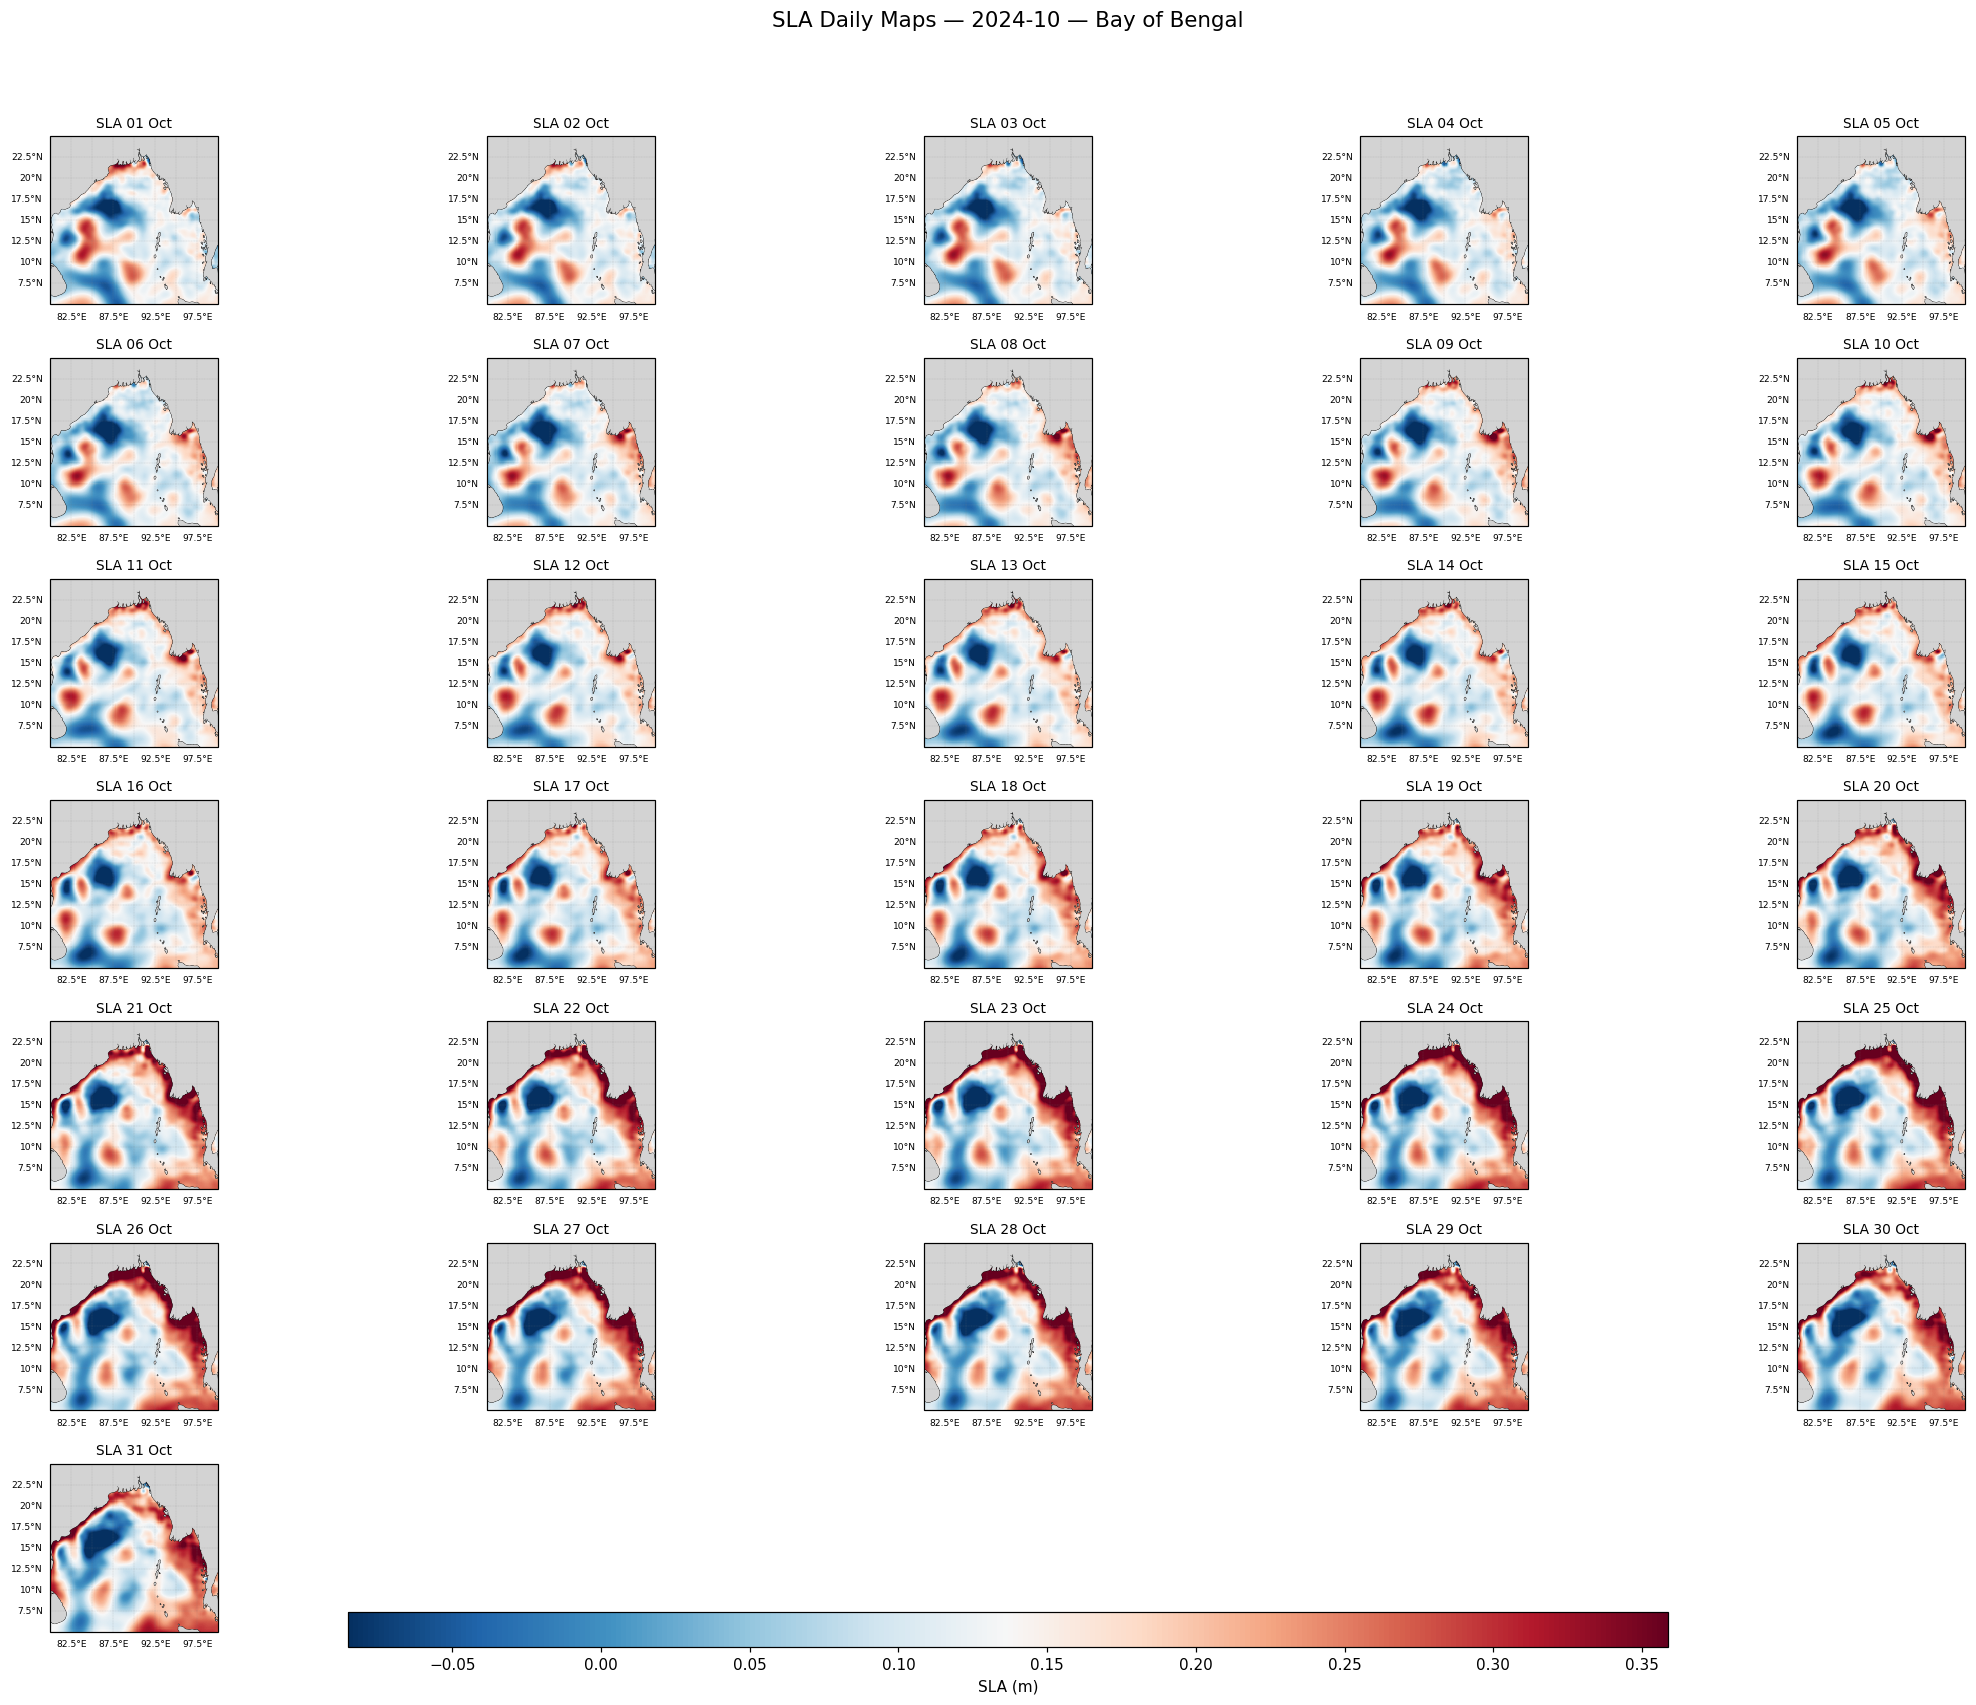

In [12]:
# Plot all days in January
fig = plot_daily_month(
    ds, YEAR, month=10, var_name="sla",
    **BBOX_BOB, ncols=5, figsize=(20, 16),
)
plt.show()

## 7. Monthly Mean Maps (3x4 Panel) — `plot_monthly_means()`

In [13]:
def plot_monthly_means(ds, year, var_name="sla",
                       lat_min=5, lat_max=25, lon_min=80, lon_max=100,
                       nrows=3, ncols=4, figsize=(16, 10), cmap="RdBu_r"):
    """
    Compute monthly mean of *var_name* and plot as a 3x4 panel with cartopy.
    """
    dsy = subset_bbox(ds, lat_min, lat_max, lon_min, lon_max)
    monthly = dsy[var_name].groupby("time.month").mean(dim="time")

    vmin = float(monthly.quantile(0.02))
    vmax = float(monthly.quantile(0.98))

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        nrows, ncols,
        subplot_kw={"projection": proj},
        figsize=figsize,
        constrained_layout=True
    )
    axes = axes.flatten()

    mesh = None
    for i in range(12):
        m = i + 1
        if m in monthly["month"].values:
            mesh = plot_map(
                axes[i], monthly.sel(month=m),
                cmap=cmap, vmin=vmin, vmax=vmax,
                title=month_labels[i],
            )
        else:
            axes[i].set_title(f"{month_labels[i]} (no data)", fontsize=9)
            axes[i].coastlines()
    
    cbar = fig.colorbar(mesh, ax=axes, orientation="horizontal",shrink=0.5, pad=0.05 )

    cbar.set_label(f"{var_name.upper()} (m)")
    
    fig.suptitle(
        f"Monthly Mean {var_name.upper()} — Bay of Bengal {year}", fontsize=14,
    )
    # plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    return fig

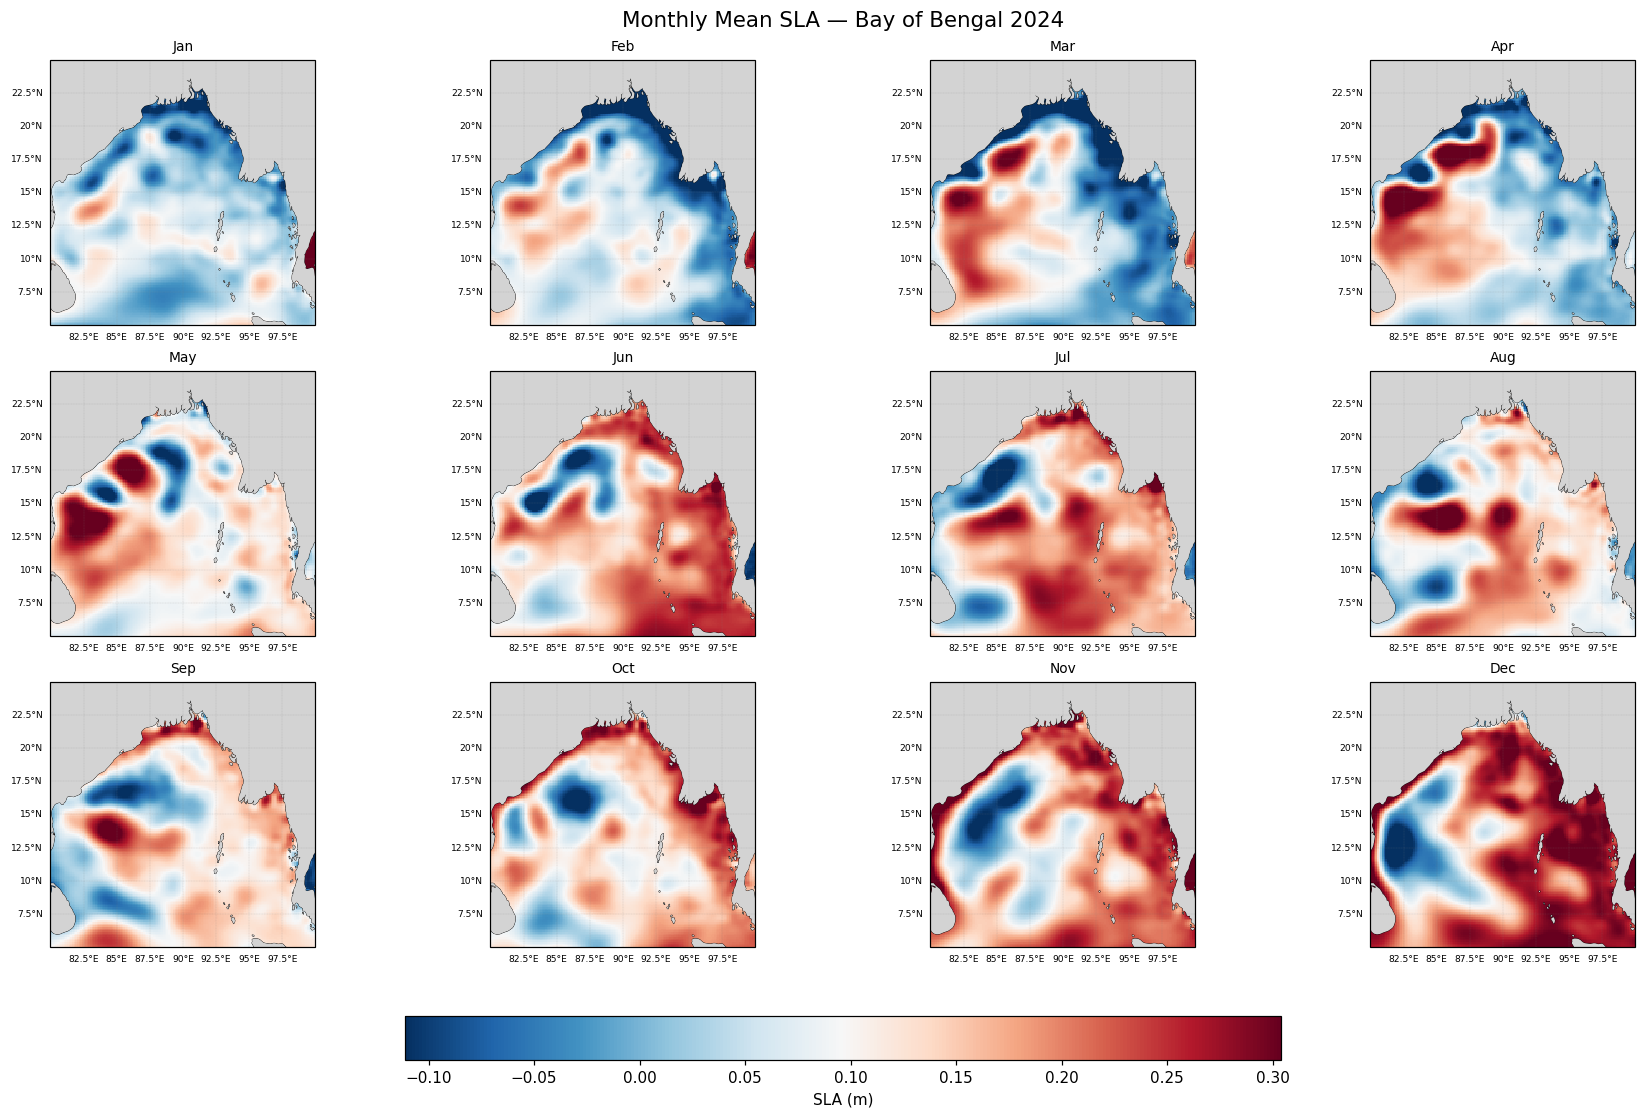

In [14]:
fig = plot_monthly_means(ds, YEAR, var_name="sla", **BBOX_BOB)
plt.show()

## 8. Area-Averaged Time Series — `plot_area_timeseries()`

In [ ]:
# def plot_area_timeseries(ds, var_name="sla",
#                          lat_min=5, lat_max=25, lon_min=80, lon_max=100,
#                          figsize=(14, 5)):
#     """
#     Daily area-averaged time series, weighted by cos(latitude) to
#     account for converging meridians.
#     """
#     dsy = subset_bbox(ds, lat_min, lat_max, lon_min, lon_max)
#     weights = np.cos(np.deg2rad(dsy.latitude))
#     ts = dsy[var_name].weighted(weights).mean(dim=["latitude", "longitude"])
#     ts_pd = ts.to_series()

#     fig, ax = plt.subplots(figsize=figsize)
#     ax.plot(ts_pd.index, ts_pd.values, lw=0.8, color="steelblue")
#     annual_mean = ts_pd.mean()
#     ax.axhline(annual_mean, ls="--", color="red", lw=0.7,
#                label=f"Annual mean = {annual_mean:.4f} m")
#     ax.fill_between(ts_pd.index, ts_pd.values, annual_mean, alpha=0.15)
#     ax.set_xlabel("Date")
#     ax.set_ylabel(f"{var_name.upper()} (m)")
#     ax.set_title(
#         f"Area-Averaged {var_name.upper()} — Bay of Bengal "
#         f"{int(ds.time.dt.year.values[0])}"
#     )
#     ax.legend()
#     ax.grid(alpha=0.3)
#     plt.tight_layout()
#     return fig

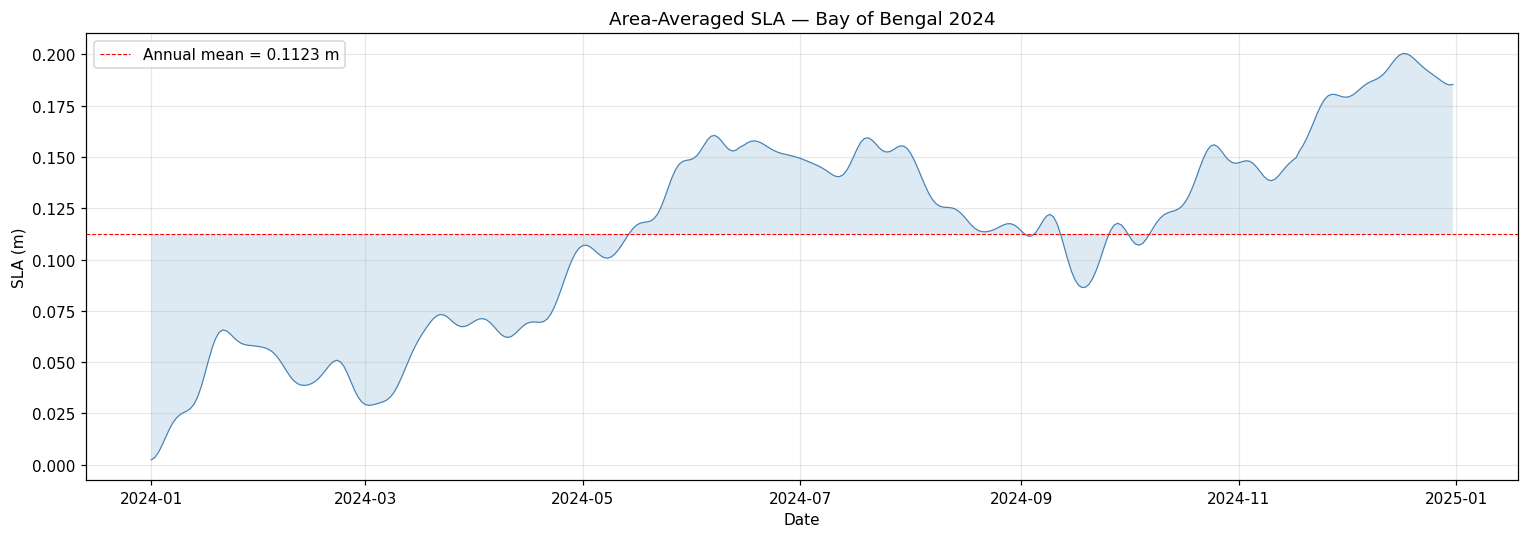

In [ ]:
# fig = plot_area_timeseries(ds, var_name="sla", **BBOX_BOB)
# plt.show()

## 9. Monthly Anomaly Maps — `plot_monthly_anomalies()`

In [ ]:
# def plot_monthly_anomalies(ds, year, var_name="sla",
#                            lat_min=5, lat_max=25, lon_min=80, lon_max=100,
#                            nrows=3, ncols=4, figsize=(16, 10), cmap="RdBu_r"):
#     """
#     Monthly anomaly = monthly_mean - annual_mean. Plotted as 3x4 panel.
#     """
#     dsy = subset_bbox(ds, lat_min, lat_max, lon_min, lon_max)
#     annual_mean = dsy[var_name].mean(dim="time")
#     monthly = dsy[var_name].groupby("time.month").mean(dim="time")
#     anomalies = monthly - annual_mean

#     vabs = float(np.abs(anomalies).quantile(0.98))

#     month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
#                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

#     proj = ccrs.PlateCarree()
#     fig, axes = plt.subplots(nrows, ncols, subplot_kw={"projection": proj},figsize=figsize, constrained_layout=True)
#     axes = axes.flatten()

#     for i in range(12):
#         anom = anomalies.sel(month=i + 1)
#         mesh = plot_map(
#             axes[i], anom,
#             cmap=cmap, vmin=-vabs, vmax=vabs,
#             title=month_labels[i],
#         )

#     cbar = fig.colorbar(mesh, ax=axes, orientation="horizontal",shrink=0.5, pad=0.05 )

#     cbar.set_label(f"{var_name.upper()} (m)")
#     fig.suptitle(
#         f"{var_name.upper()} Monthly Anomaly (vs Annual Mean) — "
#         f"Bay of Bengal {year}",
#         fontsize=14,
#     )
#     # plt.tight_layout(rect=[0, 0.04, 1, 0.95])
#     return fig

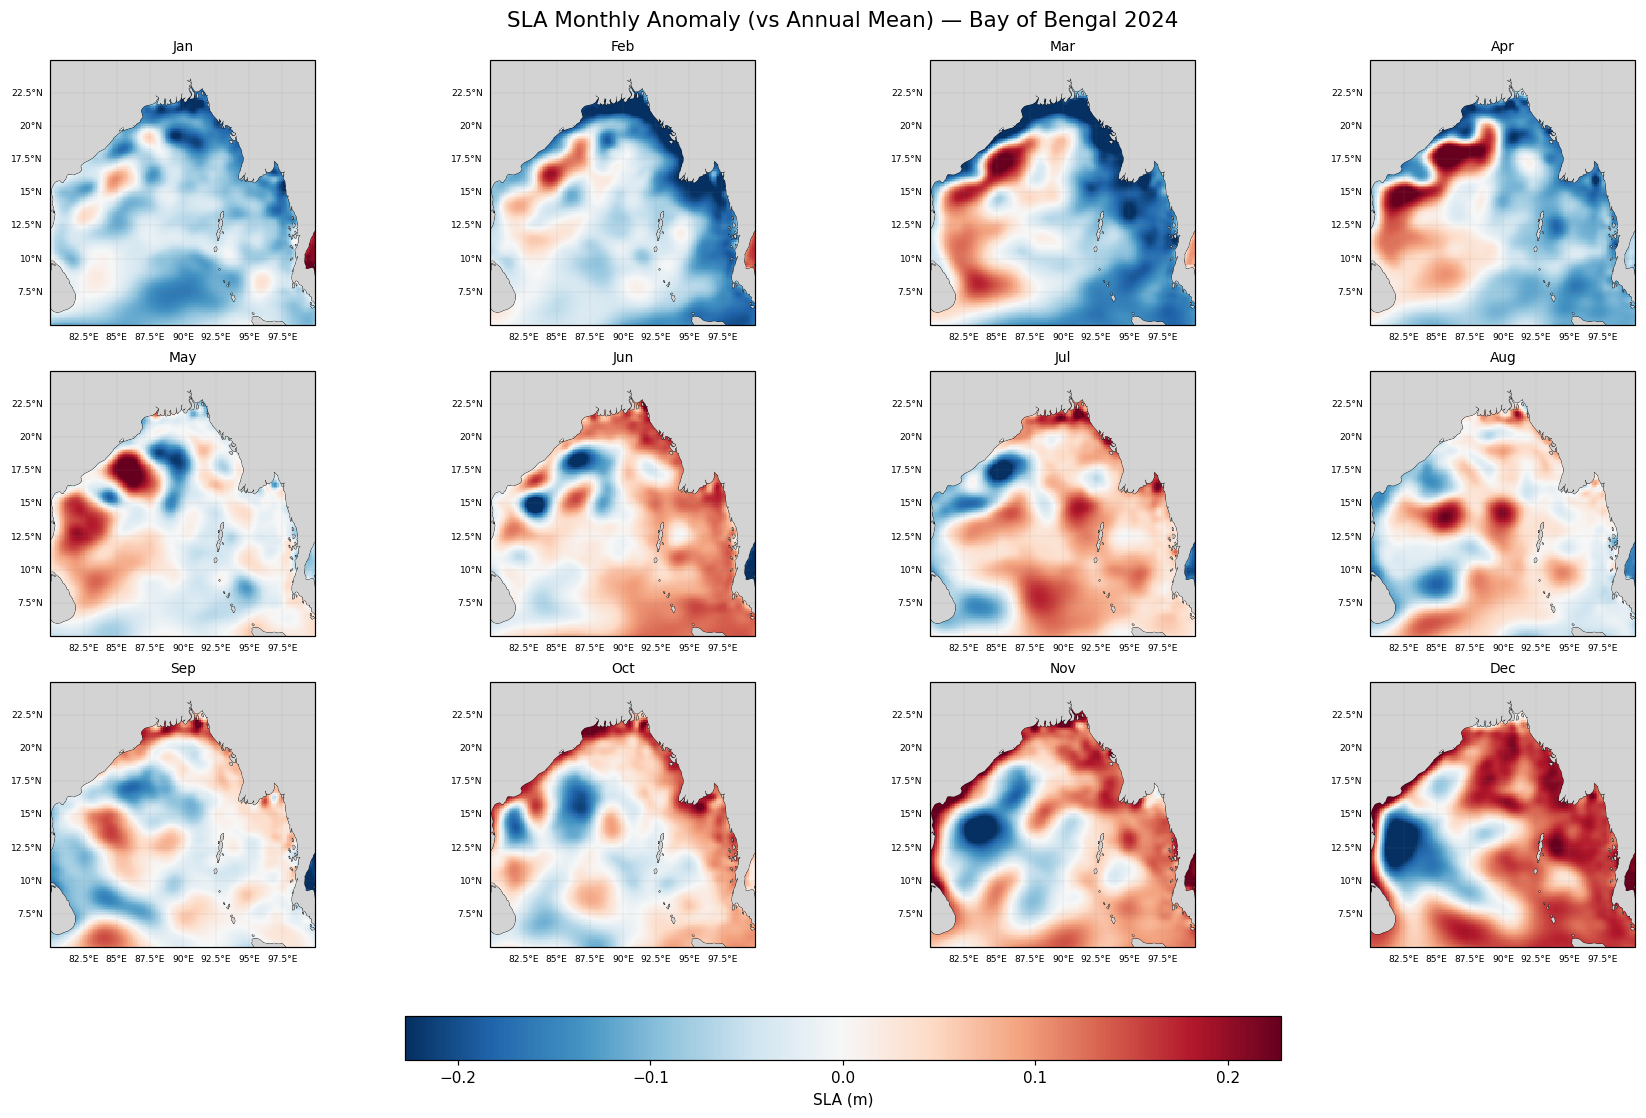

In [ ]:
# fig = plot_monthly_anomalies(ds, YEAR, var_name="sla", **BBOX_BOB)
# plt.show()

## 10. Monthly Statistics Summary

In [ ]:
# month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
#                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# ds_bob = subset_bbox(ds, **BBOX_BOB)
# rows = []
# for m in range(1, 13):
#     da_m = ds_bob["sla"].sel(time=ds_bob["time"].dt.month == m)
#     vals = da_m.values.ravel()
#     valid = vals[np.isfinite(vals)]
#     rows.append({
#         "Month": month_names[m - 1],
#         "Days": int(da_m.sizes["time"]),
#         "Mean (m)": np.mean(valid),
#         "Std (m)": np.std(valid),
#         "Min (m)": np.min(valid),
#         "Max (m)": np.max(valid),
#     })

# df_stats = pd.DataFrame(rows)
# print(df_stats.to_string(index=False))
# df_stats.to_csv("monthly_sla_statistics_2024.csv", index=False)
# print("\nSaved: monthly_sla_statistics_2024.csv")

Month  Days  Mean (m)  Std (m)  Min (m)  Max (m)
  Jan    31  0.039554 0.073015  -0.4020   0.4469
  Feb    29  0.044512 0.095511  -0.3897   0.4062
  Mar    31  0.053219 0.121887  -0.4401   0.3948
  Apr    30  0.074137 0.107465  -0.3272   0.4414
  May    31  0.118610 0.098589  -0.4520   0.4729
  Jun    30  0.154430 0.098425  -0.2890   0.6167
  Jul    31  0.149844 0.103272  -0.2931   0.6334
  Aug    31  0.123776 0.089839  -0.2893   0.5763
  Sep    30  0.107076 0.090469  -0.3092   0.5735
  Oct    31  0.131115 0.099373  -0.1997   0.5987
  Nov    30  0.155966 0.109745  -0.2168   0.6374
  Dec    31  0.189963 0.124316  -0.2668   0.6117

Saved: monthly_sla_statistics_2024.csv


## 11. Trend & Variability Analysis

Saved: sla_trends_2024.png


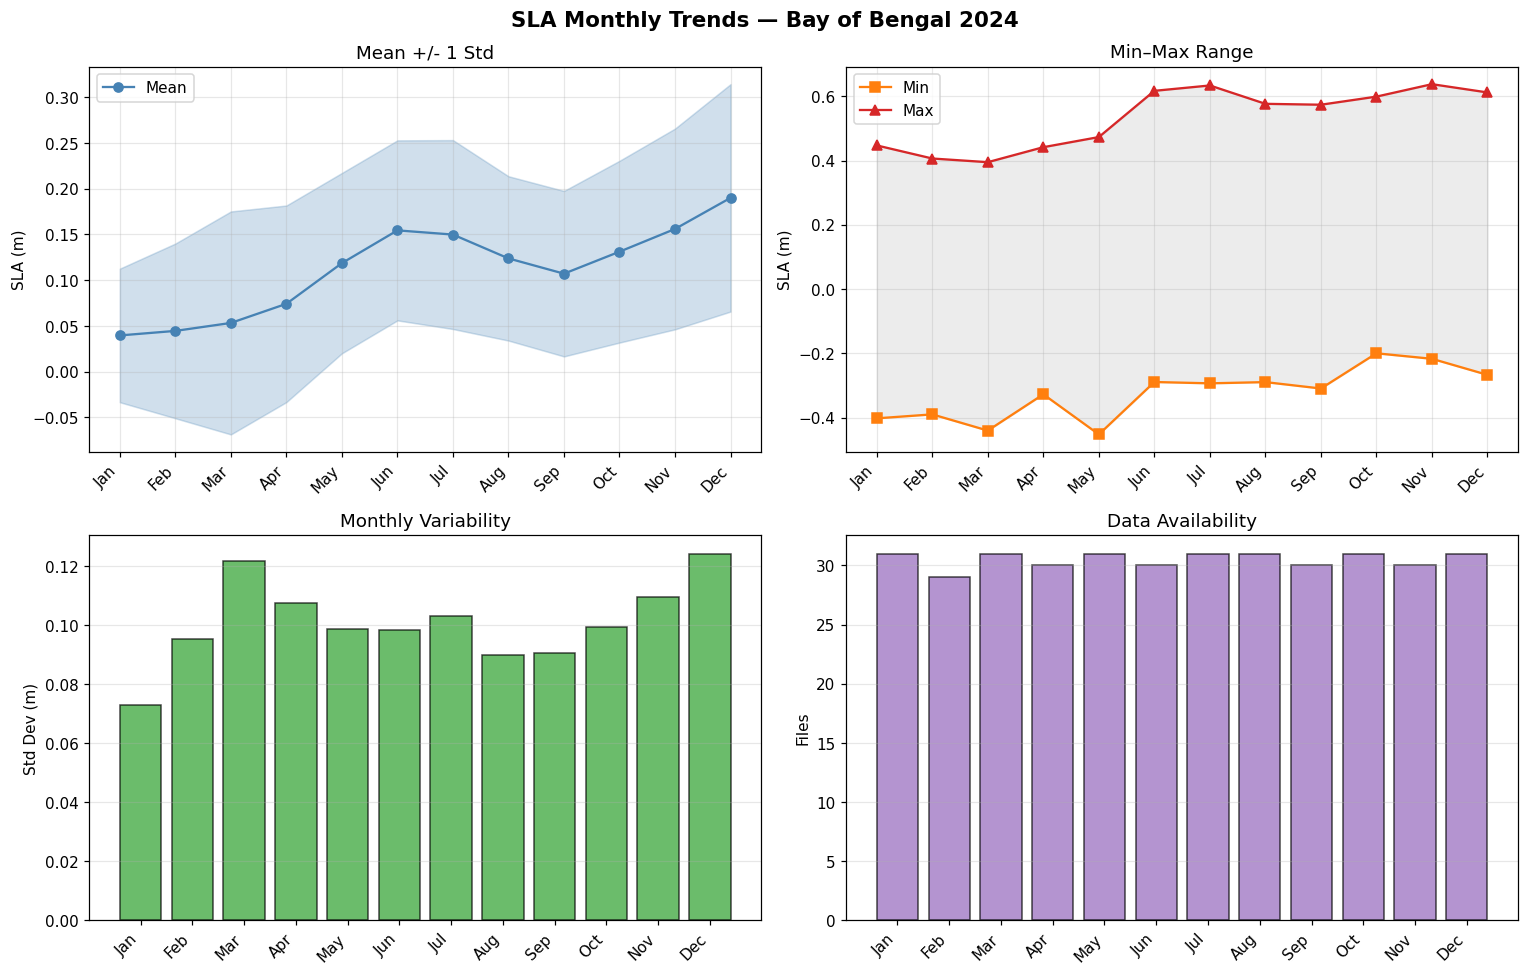

In [ ]:
# fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# fig.suptitle("SLA Monthly Trends — Bay of Bengal 2024", fontsize=14, fontweight="bold")

# x = np.arange(1, 13)

# # Mean +/- std
# ax = axes[0, 0]
# ax.plot(x, df_stats["Mean (m)"], "o-", color="steelblue", label="Mean")
# ax.fill_between(x,
#                 df_stats["Mean (m)"] - df_stats["Std (m)"],
#                 df_stats["Mean (m)"] + df_stats["Std (m)"],
#                 alpha=0.25, color="steelblue")
# ax.set_ylabel("SLA (m)")
# ax.set_title("Mean +/- 1 Std")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3)
# ax.legend()

# # Min / Max range
# ax = axes[0, 1]
# ax.plot(x, df_stats["Min (m)"], "s-", color="#ff7f0e", label="Min")
# ax.plot(x, df_stats["Max (m)"], "^-", color="#d62728", label="Max")
# ax.fill_between(x, df_stats["Min (m)"], df_stats["Max (m)"], alpha=0.15, color="gray")
# ax.set_ylabel("SLA (m)")
# ax.set_title("Min–Max Range")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3)
# ax.legend()

# # Std bar
# ax = axes[1, 0]
# ax.bar(x, df_stats["Std (m)"], color="#2ca02c", alpha=0.7, edgecolor="black")
# ax.set_ylabel("Std Dev (m)")
# ax.set_title("Monthly Variability")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3, axis="y")

# # Days per month
# ax = axes[1, 1]
# ax.bar(x, df_stats["Days"], color="#9467bd", alpha=0.7, edgecolor="black")
# ax.set_ylabel("Files")
# ax.set_title("Data Availability")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3, axis="y")

# plt.tight_layout()
# plt.savefig("sla_trends_2024.png", bbox_inches="tight")
# print("Saved: sla_trends_2024.png")
# plt.show()

## 12. Custom Region Example

Change `BBOX_CUSTOM` to any sub-region and re-use the same functions.

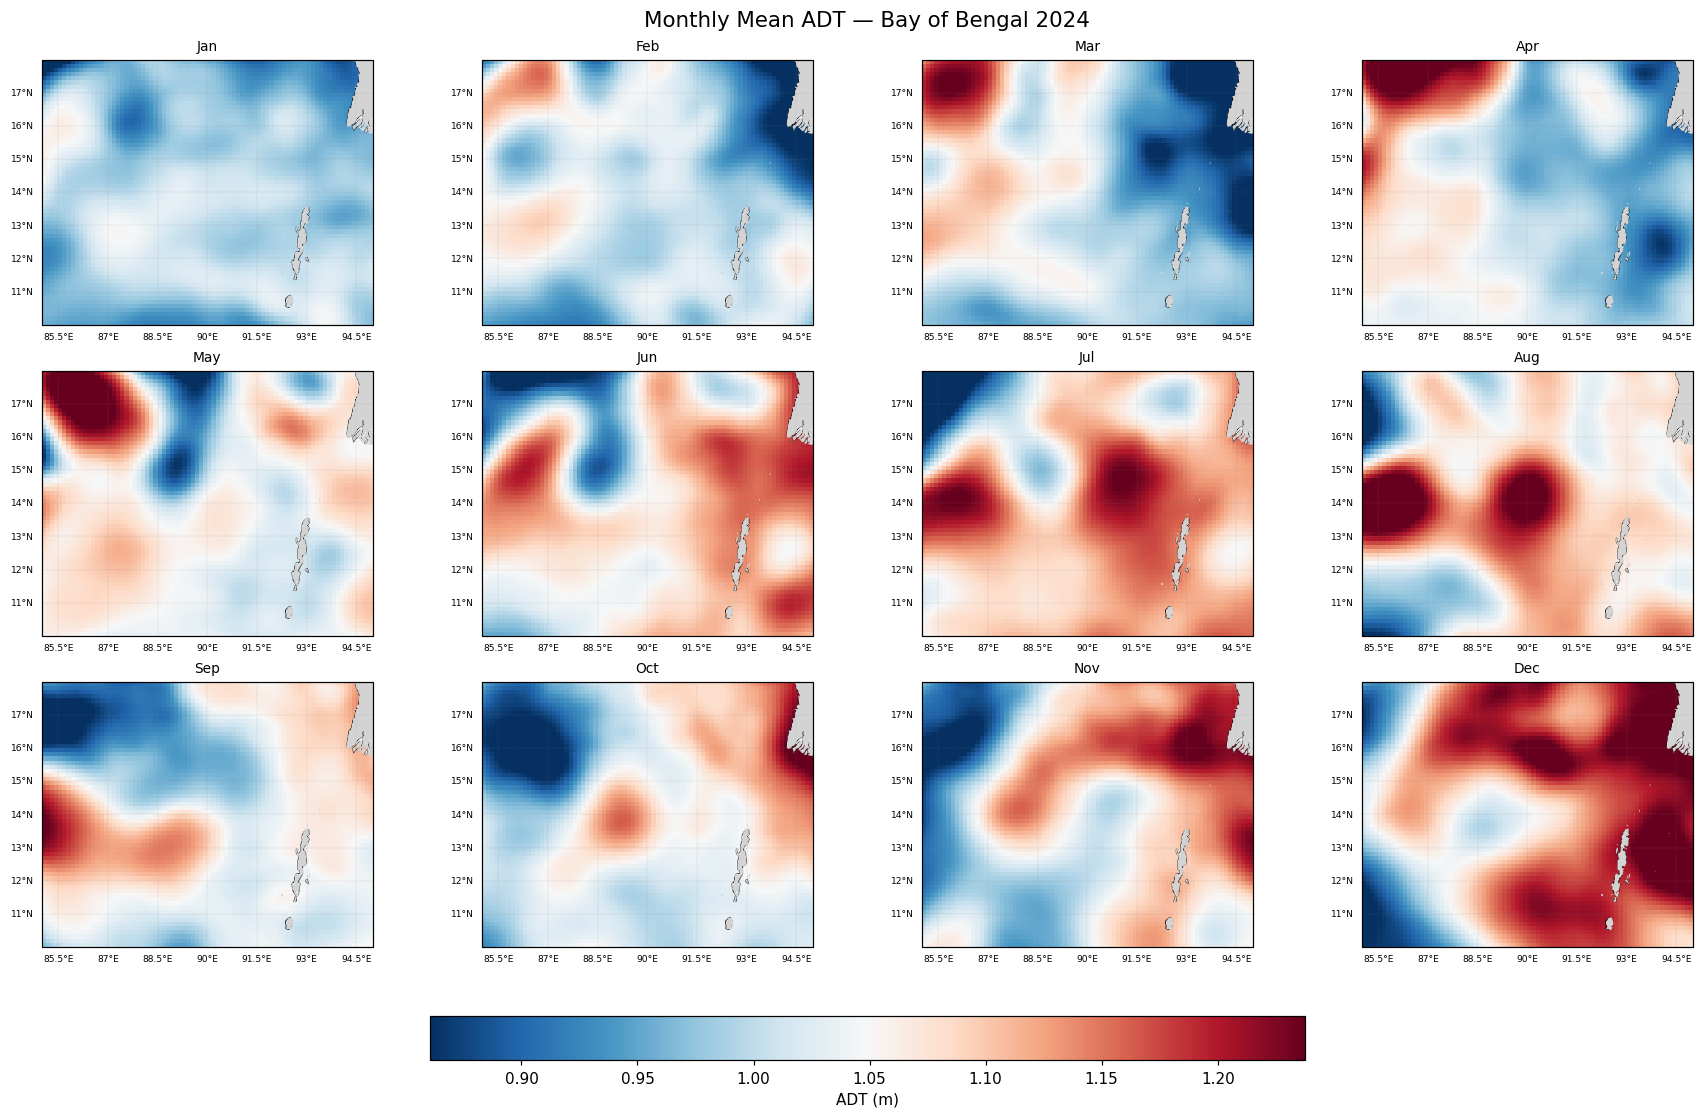

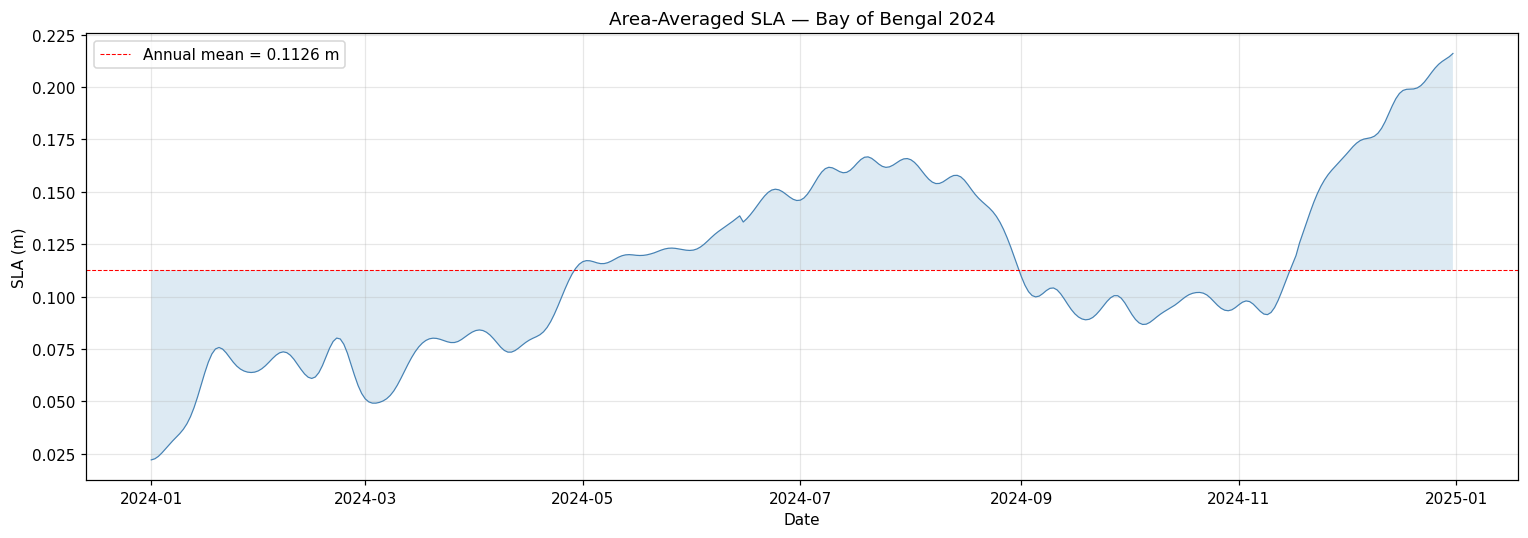

In [ ]:
# # Central Bay of Bengal eddy hotspot
# BBOX_CUSTOM = dict(lat_min=10, lat_max=18, lon_min=85, lon_max=95)

# # Monthly means for ADT in the custom region
# fig = plot_monthly_means(
#     ds, YEAR, var_name="adt", **BBOX_CUSTOM,
# )
# plt.show()

# # Time series for SLA in the custom region
# fig2 = plot_area_timeseries(ds, var_name="sla", **BBOX_CUSTOM)
# plt.show()

## 13. Other Variables: UGOSA, VGOSA

All plotting functions accept a `var_name` argument.

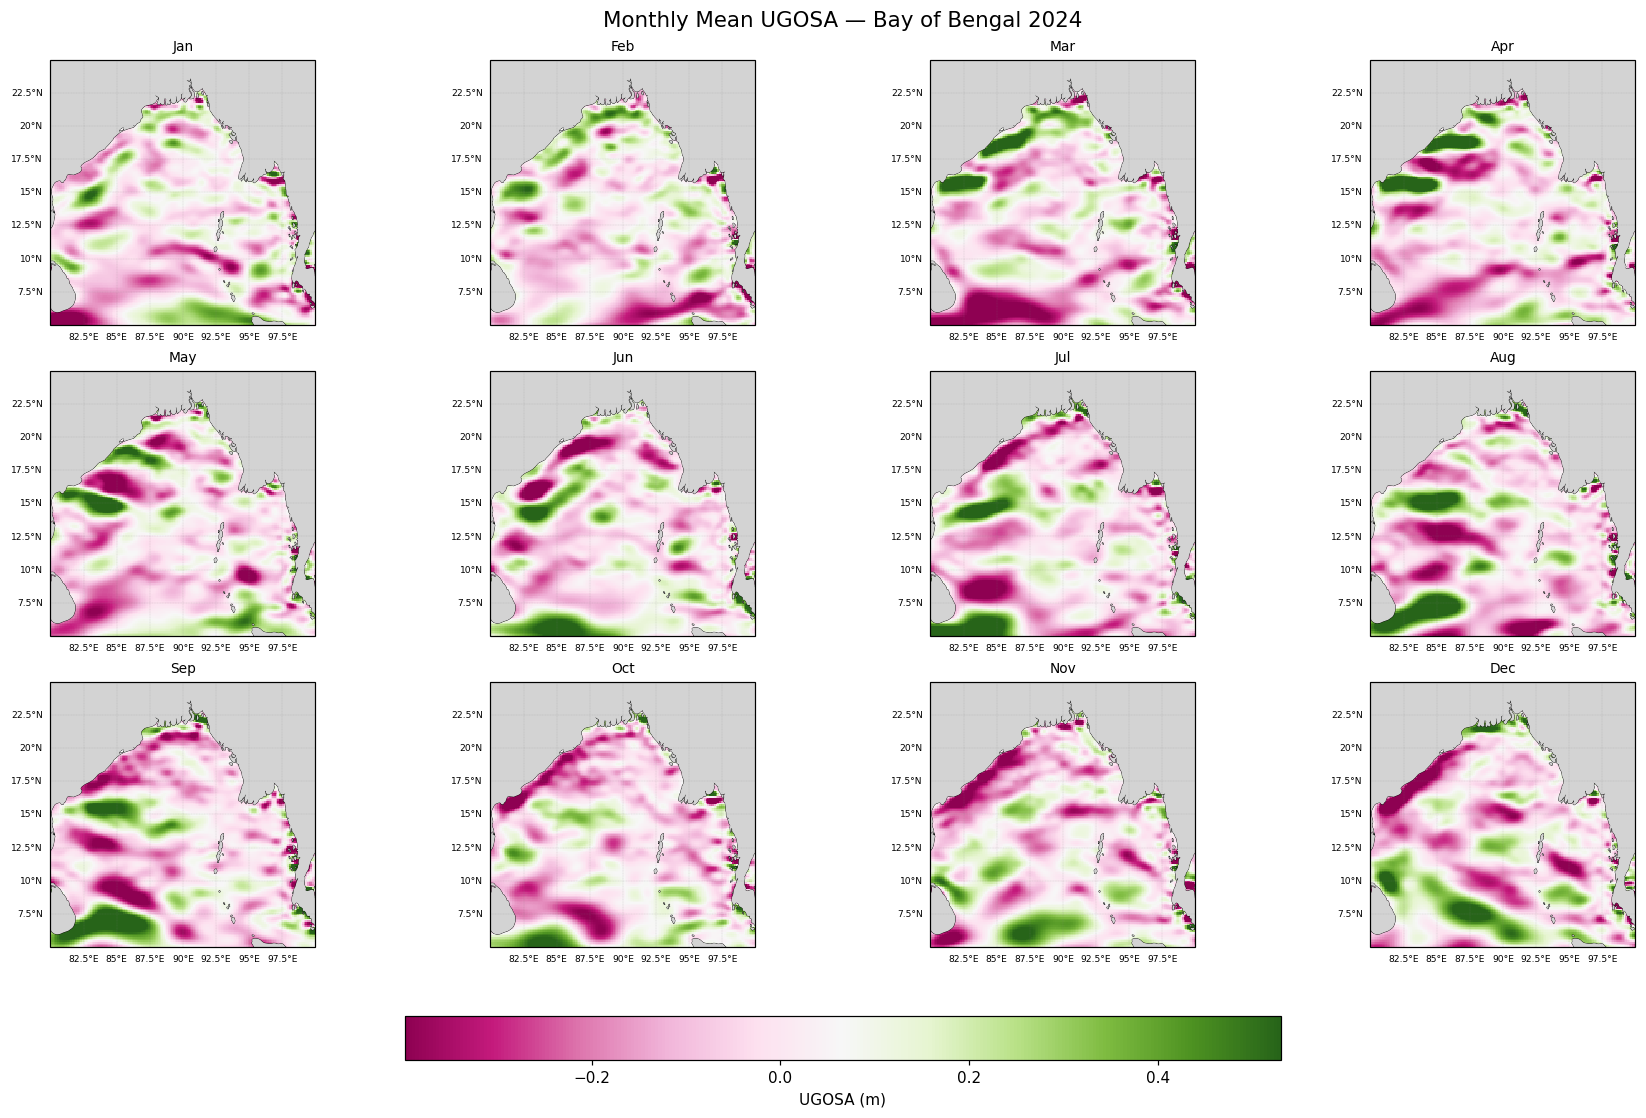

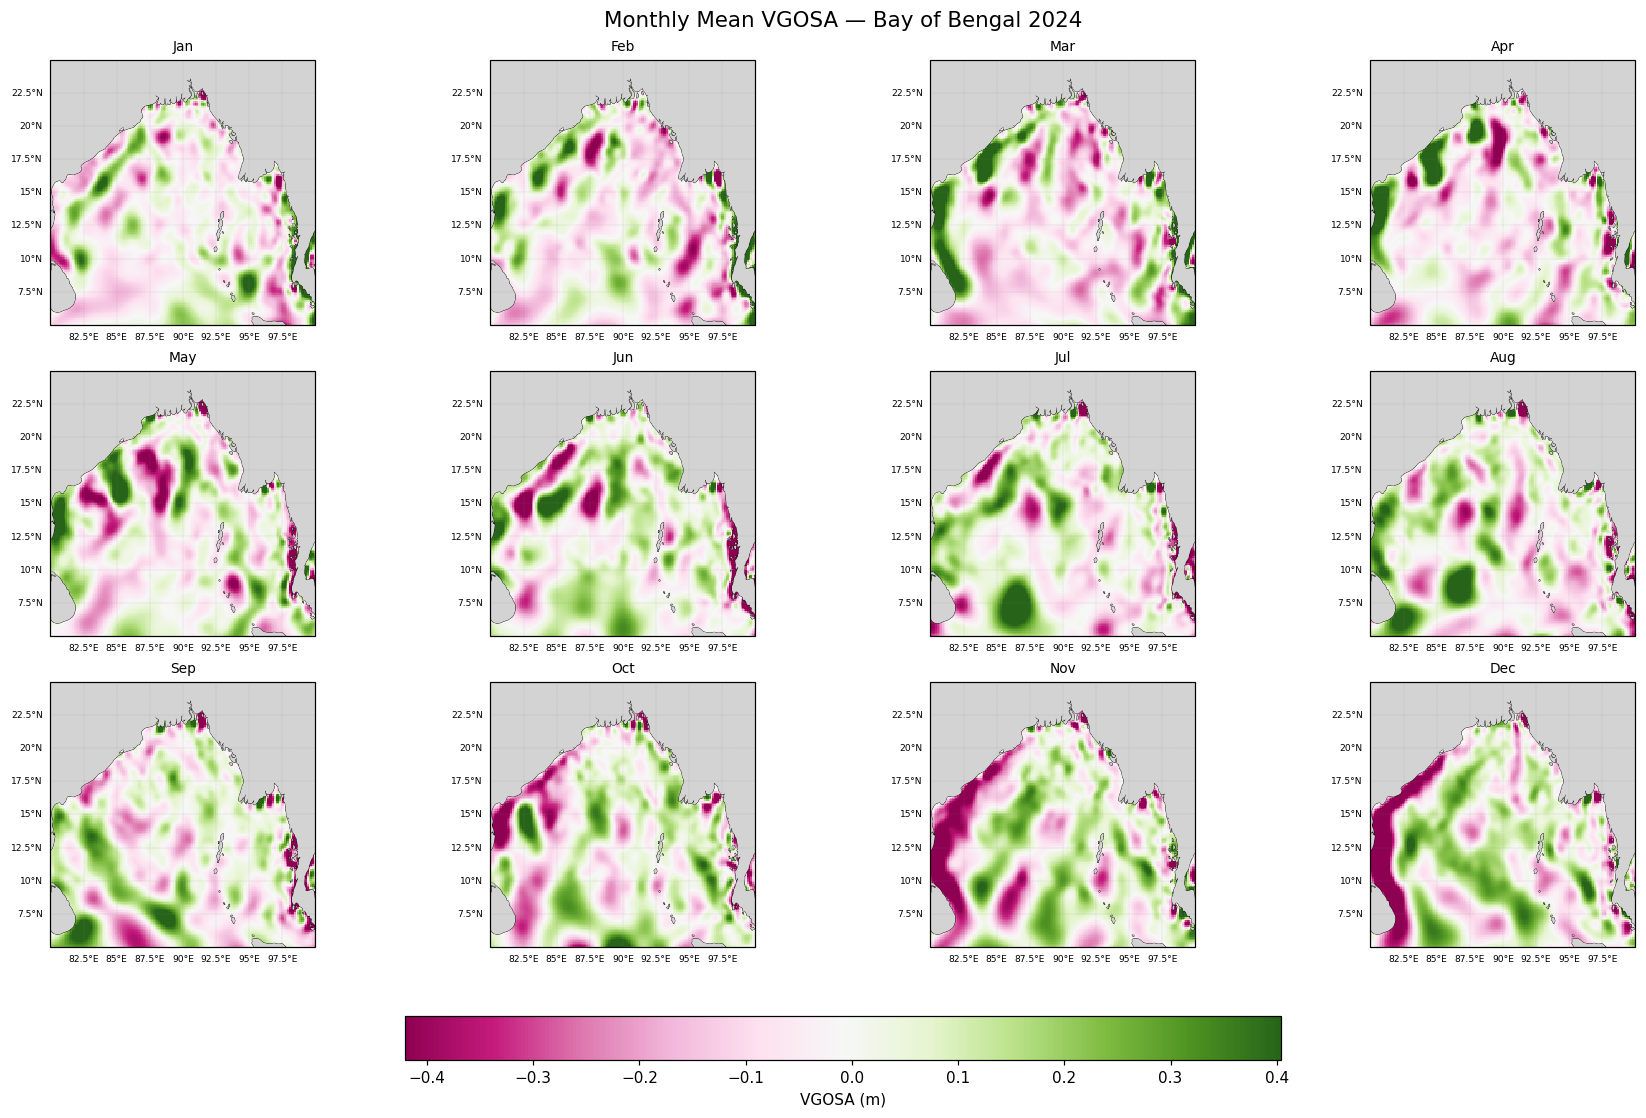

In [ ]:
# # Geostrophic velocity anomaly — monthly means
# fig = plot_monthly_means(ds, YEAR, var_name="ugosa", **BBOX_BOB, cmap="PiYG")
# plt.show()

# fig = plot_monthly_means(ds, YEAR, var_name="vgosa", **BBOX_BOB, cmap="PiYG")
# plt.show()

In [ ]:
# # Output folder for all plot files
# SAVE_DIR = r"C:\Users\abhik\Desktop\project related work\SST_Plots"
# os.makedirs(SAVE_DIR, exist_ok=True)

# def save_plot(fig, filename):
#     fig.savefig(os.path.join(SAVE_DIR, filename), bbox_inches="tight")
#     plt.close(fig)

# # 1) Daily maps (January, SLA)
# fig = plot_daily_month(ds, YEAR, month=1, var_name="sla", **BBOX_BOB, ncols=5, figsize=(20, 16))
# save_plot(fig, "daily_sla_2024_01_bob.png")

# # 2) Monthly means (SLA)
# fig = plot_monthly_means(ds, YEAR, var_name="sla", **BBOX_BOB)
# save_plot(fig, "monthly_mean_sla_2024_bob.png")

# # 3) Area-averaged time series (SLA)
# fig = plot_area_timeseries(ds, var_name="sla", **BBOX_BOB)
# save_plot(fig, "area_timeseries_sla_2024_bob.png")

# # 4) Monthly anomalies (SLA)
# fig = plot_monthly_anomalies(ds, YEAR, var_name="sla", **BBOX_BOB)
# save_plot(fig, "monthly_anomaly_sla_2024_bob.png")

# # 5) Trend & variability summary plot
# fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# fig.suptitle("SLA Monthly Trends — Bay of Bengal 2024", fontsize=14, fontweight="bold")

# x = np.arange(1, 13)

# ax = axes[0, 0]
# ax.plot(x, df_stats["Mean (m)"], "o-", color="steelblue", label="Mean")
# ax.fill_between(
#     x,
#     df_stats["Mean (m)"] - df_stats["Std (m)"],
#     df_stats["Mean (m)"] + df_stats["Std (m)"],
#     alpha=0.25, color="steelblue"
# )
# ax.set_ylabel("SLA (m)")
# ax.set_title("Mean +/- 1 Std")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3)
# ax.legend()

# ax = axes[0, 1]
# ax.plot(x, df_stats["Min (m)"], "s-", color="#ff7f0e", label="Min")
# ax.plot(x, df_stats["Max (m)"], "^-", color="#d62728", label="Max")
# ax.fill_between(x, df_stats["Min (m)"], df_stats["Max (m)"], alpha=0.15, color="gray")
# ax.set_ylabel("SLA (m)")
# ax.set_title("Min–Max Range")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3)
# ax.legend()

# ax = axes[1, 0]
# ax.bar(x, df_stats["Std (m)"], color="#2ca02c", alpha=0.7, edgecolor="black")
# ax.set_ylabel("Std Dev (m)")
# ax.set_title("Monthly Variability")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3, axis="y")

# ax = axes[1, 1]
# ax.bar(x, df_stats["Days"], color="#9467bd", alpha=0.7, edgecolor="black")
# ax.set_ylabel("Files")
# ax.set_title("Data Availability")
# ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45, ha="right")
# ax.grid(alpha=0.3, axis="y")

# plt.tight_layout()
# save_plot(fig, "sla_trends_2024_bob.png")

# # 6) Custom region plots
# fig = plot_monthly_means(ds, YEAR, var_name="adt", **BBOX_CUSTOM)
# save_plot(fig, "monthly_mean_adt_2024_custom.png")

# fig = plot_area_timeseries(ds, var_name="sla", **BBOX_CUSTOM)
# save_plot(fig, "area_timeseries_sla_2024_custom.png")

# # 7) Other variables
# fig = plot_monthly_means(ds, YEAR, var_name="ugosa", **BBOX_BOB, cmap="PiYG")
# save_plot(fig, "monthly_mean_ugosa_2024_bob.png")

# fig = plot_monthly_means(ds, YEAR, var_name="vgosa", **BBOX_BOB, cmap="PiYG")
# save_plot(fig, "monthly_mean_vgosa_2024_bob.png")

# print(f"All plots saved to:\n{SAVE_DIR}")

All plots saved to:
C:\Users\abhik\Desktop\project related work\SST_Plots
